# Malware Classification

## The Malware Dataset

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

DATA_BASE_PATH = "./malimg_paper_dataset_imgs/"

In [2]:
# count the number of images and compute the overall class distribution
dist = {}
for mlw_class in os.listdir(DATA_BASE_PATH):
    mlw_dir = os.path.join(DATA_BASE_PATH, mlw_class)
    dist[mlw_class] = len(os.listdir(mlw_dir))

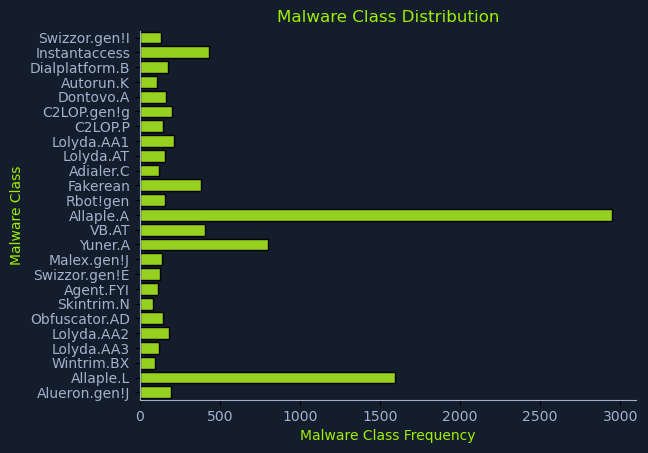

In [3]:
# plot the class distribution

# HTB color palette
htb_green = "#9FEF00"
node_black = "#141D2B"
hacker_grey = "#A4B1CD"

# data
classes = list(dist.keys())
frequencies = list(dist.values())

# plot
plt.figure(facecolor=node_black)
sns.barplot(
    y = classes,
    x = frequencies,
    edgecolor = "black",
    orient = 'h',
    color=htb_green
)

plt.title("Malware Class Distribution", color = htb_green)
plt.xlabel("Malware Class Frequency", color = htb_green)
plt.ylabel("Malware Class", color=htb_green)
plt.xticks(color=hacker_grey)
plt.yticks(color=hacker_grey)

ax = plt.gca()
ax.set_facecolor(node_black)
ax.spines['bottom'].set_color(hacker_grey)
ax.spines['top'].set_color(node_black)
ax.spines['right'].set_color(node_black)
ax.spines['left'].set_color(hacker_grey)
plt.show()

## Preprocessing the Malware Dataset

In [4]:
# note: need to install split-folders library
# it splits (organize) the images into folders for training and testing
import splitfolders
from pathlib import Path
DATA_BASE_PATH = "./malimg_paper_dataset_imgs/"
TARGET_BASE_PATH = "./newdata/"

if not Path(TARGET_BASE_PATH).is_dir():

    TRAINING_RATIO = 0.8
    TEST_RATIO = 1 - TRAINING_RATIO
    
    splitfolders.ratio(
        input=DATA_BASE_PATH,
        output=TARGET_BASE_PATH,
        ratio=(TRAINING_RATIO, 0, TEST_RATIO)
    )
else:
    print(f"{TARGET_BASE_PATH} already exists!")

./newdata/ already exists!


In [5]:
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import os

BASE_PATH = "./newdata/"
TRAIN_BATCH_SIZE = 1024
TEST_BATCH_SIZE = 1024


def load_datasets(base_path, train_batch_size, test_batch_size):
    # Define preprocessing transforms
    transform = transforms.Compose([
        transforms.Resize((75, 75)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load training and test datasets
    train_dataset = ImageFolder(
        root=os.path.join(base_path, "train"),
        transform=transform
    )

    test_dataset = ImageFolder(
        root=os.path.join(base_path, "test"),
        transform=transform
    )

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=2
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=2
    )

    n_classes = len(train_dataset.classes)
    return train_loader, test_loader, n_classes

train_loader, test_loader, n_classes = load_datasets(BASE_PATH, TRAIN_BATCH_SIZE, TEST_BATCH_SIZE)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


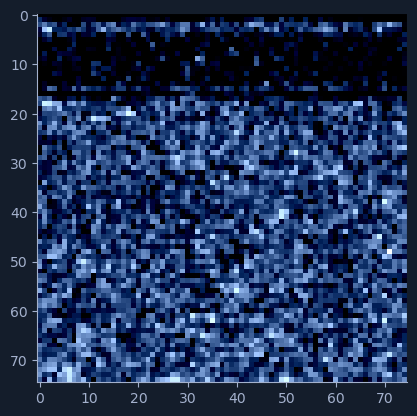

In [6]:
# show one of the preprocessed images
import matplotlib.pyplot as plt

# HTB Color Palette
htb_green = "#9FEF00"
node_black = "#141D2B"
hacker_grey = "#A4B1CD"

# image
sample = next(iter(train_loader))[0][0]

# plot
plt.figure(facecolor=node_black)
plt.imshow(sample.permute(1,2,0))
plt.xticks(color=hacker_grey)
plt.yticks(color=hacker_grey)
ax = plt.gca()
ax.set_facecolor(node_black)
ax.spines['bottom'].set_color(hacker_grey)
ax.spines['top'].set_color(node_black)
ax.spines['right'].set_color(node_black)
ax.spines['left'].set_color(hacker_grey)
ax.tick_params(axis='x', colors=hacker_grey)
ax.tick_params(axis='y', colors=hacker_grey)
plt.show()

## The Model

In [7]:
import torch.nn as nn
import torchvision.models as models

HIDDEN_LAYER_SIZE = 1000

class MalwareClassifier(nn.Module):
    def __init__(self, n_classes):
        super(MalwareClassifier, self).__init__()

        # Load pretrained ResNet50
        self.resnet = models.resnet50(weights='DEFAULT')

        # Freeze ResNet parameters
        for param in self.resnet.parameters():
            param.requires_grad = False

        # replace the last fully connected layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, HIDDEN_LAYER_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_LAYER_SIZE, n_classes)
        )

    def forward(self, x):
        return self.resnet(x)

In [8]:
# using the model
DATA_PATH = "./newdata/"
TRAINING_BATCH_SIZE = 1024
TEST_BATCH_SIZE = 1024
# loading the datasets
train_loader, test_loader, n_classes = load_datasets(
    DATA_PATH,
    TRAIN_BATCH_SIZE,
    TEST_BATCH_SIZE
)

model = MalwareClassifier(n_classes)

## Training and Evaluation

In [9]:
# final training function
import torch
import time

def train(model, train_loader, n_epochs, verbose = False):
    model.train()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())

    training_data = {
        "accuracy": [], 
        "loss": []
    }

    for epoch in range(n_epochs):
        running_loss = 0
        n_total = 0
        n_correct = 0
        ckeckpoint = time.time() * 1000

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            n_total += labels.size(0)
            n_correct += predicted.eq(labels).sum().item()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        epoch_duration = int(time.time() * 1000 - ckeckpoint)
        epoch_accuracy = compute_accuracy(n_correct, n_total)

        training_data["accuracy"].append(epoch_accuracy)
        training_data["loss"].append(epoch_loss)

        if verbose:
            print(f"[i] Epoch {epoch+ 1} of {n_epochs}: Acc: {epoch_accuracy:.2f}% Loss: {epoch_loss:.4f} (Took {epoch_duration} mx).")

        return training_data
            

In [10]:
# save the model

def save_model(model, path):
    model_scripted = torch.jit.script(model)
    model_scripted.save(path)
    

In [11]:
# Create the prediciton funciton that runs the model on a single input and returns the predicted class
# this will be used to evaluate the model

def predict(model, test_data):
    model.eval() # sets the model for evalution mode

    with torch.no_grad(): # with gradient calculation disabled
        output = model(test_data)
        _, predicted = torch.max(output.data, 1)

    return predicted

In [12]:
# compute the accuracy

def compute_accuracy(n_correct, n_total):
    return round(100 * n_correct / n_total, 2)

def evaluate(model, test_loader):
    model.eval()

    n_correct = 0
    n_total = 0

    with torch.no_grad():
        for data, target in test_loader:
            predicted = predict(model, data)
            n_total += target.size(0)
            n_correct += (predicted == target).sum().item()

    accuracy = compute_accuracy(n_correct, n_total)

    return accuracy
                     

In [13]:
# helper functions to create simple plots

import matplotlib.pyplot as plt

def plot(data, title, label, xlabel, ylabel):
    # HTB Color Palette
    htb_green = "#9FEF00"
    node_black = "#141D2B"
    hacker_grey = "#A4B1CD"

    # create the plot
    plt.figure(figsize=(10, 6), facecolor=node_black)
    plt.plot(range(1, len(data)+1), data, label=label, color=htb_green)
    plt.title(title, color=htb_green)
    plt.xlabel(xlabel, color=htb_green)
    plt.ylabel(ylabel, color=htb_green)
    plt.xticks(color=hacker_grey)
    plt.yticks(color=hacker_grey)
    ax = plt.gca()
    ax.set_facecolor(node_black)
    ax.spines['bottom'].set_color(hacker_grey)
    ax.spines['top'].set_color(node_black)
    ax.spines['right'].set_color(node_black)
    ax.spines['left'].set_color(hacker_grey)

    legend = plt.legend(
        facecolor = node_black,
        edgecolor = hacker_grey,
        fontsize = 10
    )

    plt.setp(legend.get_texts(), color=htb_green)
    plt.show()

def plot_training_accuracy(training_data):
    plot(
        training_data['accuracy'],
        "Training Accuracy",
        "Accuracy",
        "Epoch",
        "Accuracy (%)"
    )

def plot_training_loss(training_data):
    plot(
        training_data['loss'],
        "Training Loss",
        "Loss",
        "Epoch",
        "Loss"
    )

[i] Starting Training...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
[i] Epoch 1 of 10: Acc: 45.98% Loss: 1.9219 (Took 99683 mx).
[i] Inference accuracy: 42.77%.


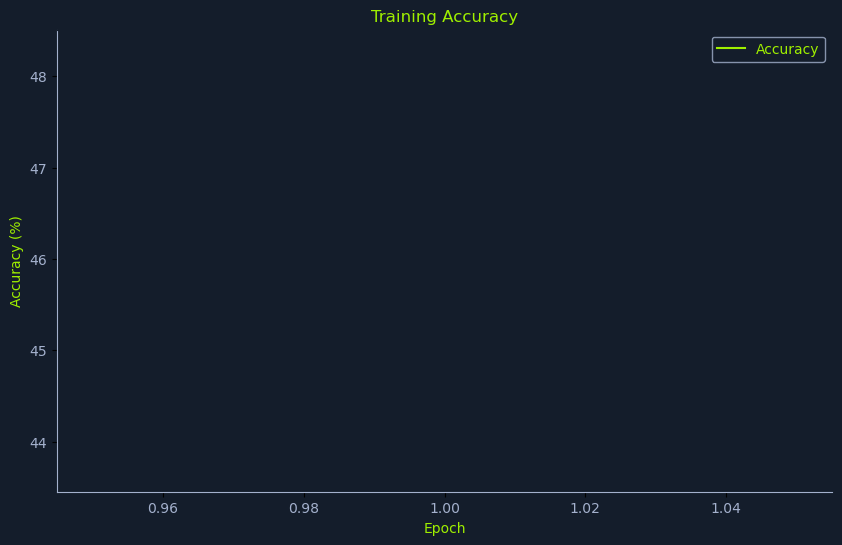

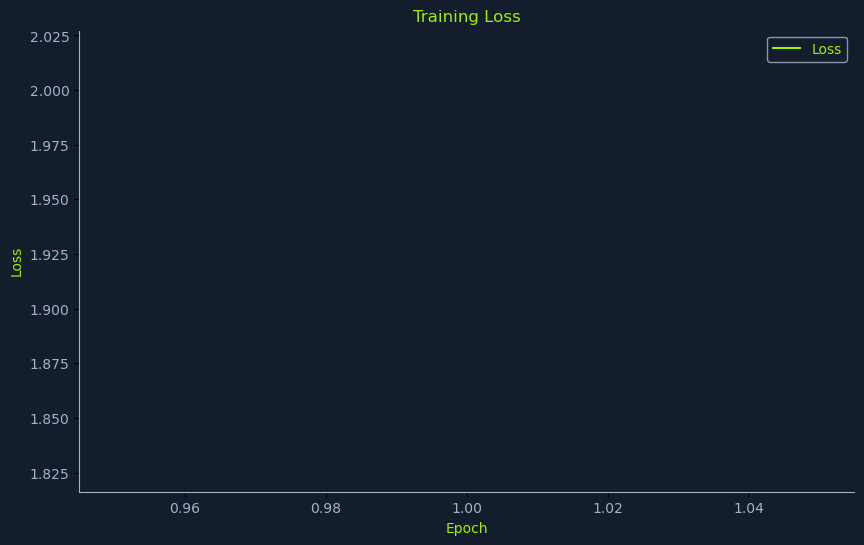

In [14]:
DATA_PATH = "./newdata/"

# training parameters
N_EPOCHS = 10
HIDDEN_LAYER_SIZE = 1000
MODEL_FILE = "malware_classifier.pth"

# Load datasets
train_loader, test_loader, n_classes = load_datasets(
    DATA_PATH,
    TRAIN_BATCH_SIZE,
    TEST_BATCH_SIZE
)

# initialize the model
model = MalwareClassifier(n_classes)

# train the model
print("[i] Starting Training...")
training_information = train(model, train_loader, N_EPOCHS, verbose=True)

# save the model
save_model(model, MODEL_FILE)

# evaluate the model
accuracy = evaluate(model, test_loader)
print(f"[i] Inference accuracy: {accuracy}%.")

plot_training_accuracy(training_information)
plot_training_loss(training_information)